**Datset 1**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()               # click "Choose Files" and pick the CSV
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Rows, columns:", df.shape)
print(df.columns.tolist())
df.head()

Saving customer_support_tickets.csv to customer_support_tickets (1).csv
Rows, columns: (8469, 17)
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [2]:
# Change these 3 names if your column names are different
TEXT_COL = "Ticket Description"
CATEGORY_COL = "Ticket Type"
PRIORITY_COL = "Ticket Priority"

print(df[CATEGORY_COL].value_counts())
print()
print(df[PRIORITY_COL].value_counts())

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


In [3]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()                    # lowercase
    text = re.sub(r"[^a-z\s]", " ", text)       # remove punctuation, numbers, { }
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(words)

# Use the subject and the description together
df["raw_text"] = df["Ticket Subject"].fillna("") + " " + df["Ticket Description"].fillna("")
df["clean_text"] = df["raw_text"].apply(clean_text)

df[["raw_text", "clean_text"]].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,raw_text,clean_text
0,Product setup I'm having an issue with the {pr...,product setup issue product purchased please a...
1,Peripheral compatibility I'm having an issue w...,peripheral compatibility issue product purchas...
2,Network problem I'm facing a problem with my {...,network problem facing problem product purchas...
3,Account access I'm having an issue with the {p...,account access issue product purchased please ...
4,Data loss I'm having an issue with the {produc...,data loss issue product purchased please assis...


In [5]:
df["priority_3"] = df["Ticket Priority"].replace({"Critical": "High"})
print(df["priority_3"].value_counts())

priority_3
High      4214
Medium    2192
Low       2063
Name: count, dtype: int64


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X = tfidf.fit_transform(df["clean_text"])

for label_col, name in [("Ticket Type", "CATEGORY"), ("priority_3", "PRIORITY")]:
    y = df[label_col]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, model.predict(X_te))
    guess = y.value_counts(normalize=True).max()
    print(f"{name}: accuracy = {acc:.1%}  |  always guessing the biggest class = {guess:.1%}")

CATEGORY: accuracy = 21.1%  |  always guessing the biggest class = 20.7%
PRIORITY: accuracy = 46.2%  |  always guessing the biggest class = 49.8%


**Dataset 2**

In [8]:
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df2 = pd.read_csv(filename)

print("Rows, columns:", df2.shape)
print(df2.columns.tolist())
display(df2.head())

Saving all_tickets_processed_improved_v3.csv to all_tickets_processed_improved_v3 (1).csv
Rows, columns: (47837, 2)
['Document', 'Topic_group']


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


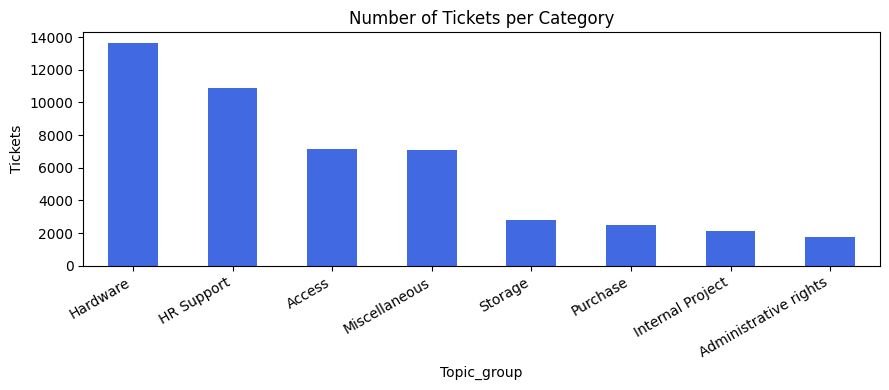

In [9]:
CATEGORY_COL = "Topic_group"
TEXT_COL = "Document"

counts = df2[CATEGORY_COL].value_counts()
print(counts)

counts.plot(kind="bar", figsize=(9,4), color="royalblue")
plt.title("Number of Tickets per Category")
plt.ylabel("Tickets")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("t2_01_category_counts.png", dpi=150)
plt.show()

In [10]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(words)

df2 = df2.dropna(subset=[TEXT_COL, CATEGORY_COL]).copy()
df2["clean_text"] = df2[TEXT_COL].apply(clean_text)
df2 = df2[df2["clean_text"].str.len() > 0]      # drop tickets that became empty

print("Tickets left:", len(df2))
df2[[TEXT_COL, "clean_text"]].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Tickets left: 47835


,Document,clean_text
0,connection with icon icon dear please setup ic...,connection icon icon dear please setup icon pe...
1,work experience user work experience user hi w...,work experience user work experience user work...
2,requesting for meeting requesting meeting hi p...,requesting meeting requesting meeting please h...
3,reset passwords for external accounts re expir...,reset passwords external accounts expire days ...
4,mail verification warning hi has got attached ...,mail verification warning got attached please ...


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = tfidf.fit_transform(df2["clean_text"])
y = df2[CATEGORY_COL]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_tr, y_tr)
pred = model.predict(X_te)

acc = accuracy_score(y_te, pred)
guess = y.value_counts(normalize=True).max()
print(f"Accuracy: {acc:.1%}  |  always guessing the biggest class: {guess:.1%}\n")
print(classification_report(y_te, pred))

Accuracy: 85.3%  |  always guessing the biggest class: 28.5%

                       precision    recall  f1-score   support

               Access       0.92      0.88      0.90      1425
Administrative rights       0.91      0.60      0.72       352
           HR Support       0.86      0.87      0.86      2183
             Hardware       0.79      0.89      0.83      2723
     Internal Project       0.92      0.81      0.86       424
        Miscellaneous       0.84      0.82      0.83      1412
             Purchase       0.97      0.87      0.92       493
              Storage       0.93      0.83      0.88       555

             accuracy                           0.85      9567
            macro avg       0.89      0.82      0.85      9567
         weighted avg       0.86      0.85      0.85      9567



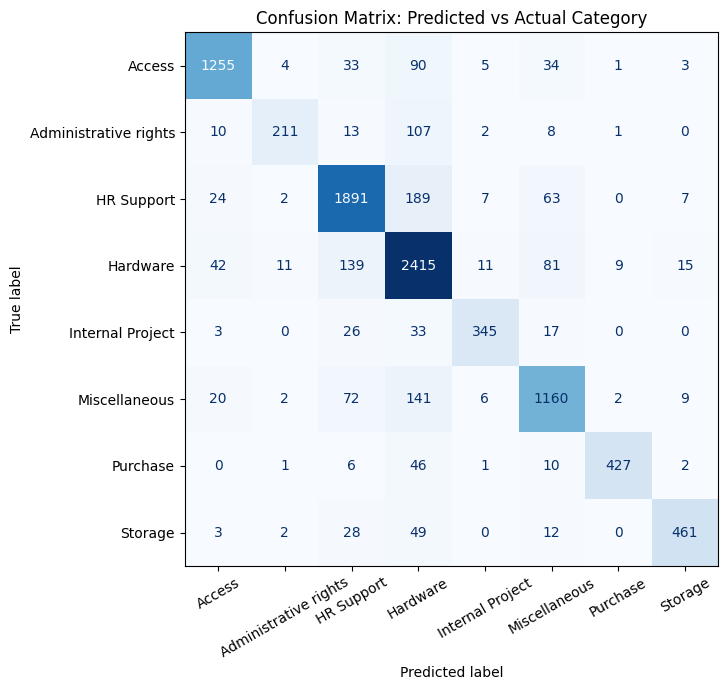

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8,7))
ConfusionMatrixDisplay.from_predictions(
    y_te, pred, ax=ax, xticks_rotation=30, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix: Predicted vs Actual Category")
plt.tight_layout()
plt.savefig("t2_02_confusion_matrix.png", dpi=150)
plt.show()

priority
High       3295
Medium    27095
Low       17445
Name: count, dtype: int64


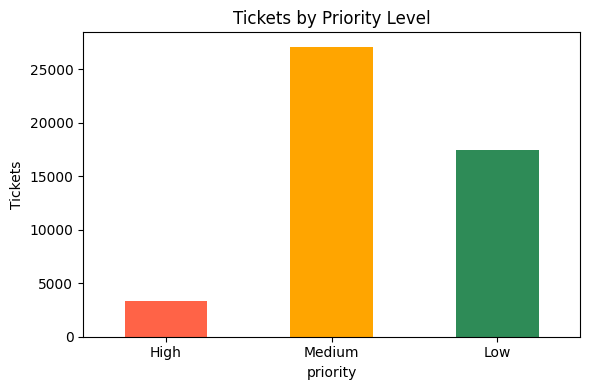

In [13]:
urgent_words = {"urgent", "asap", "immediately", "emergency", "critical", "outage",
                "down", "crashed", "crash", "breach", "virus", "hacked",
                "ransomware", "deadline", "production"}
problem_words = {"error", "failed", "failure", "unable", "cannot", "locked",
                 "blocked", "broken", "slow", "issue", "problem", "stuck",
                 "expired", "missing"}
high_impact_categories = {"Access", "Hardware", "Storage"}

def assign_priority(clean, category):
    words = set(clean.split())
    score = 0
    if words & urgent_words:
        score += 3
    if words & problem_words:
        score += 1
    if category in high_impact_categories:
        score += 1
    if score >= 3:
        return "High"
    elif score >= 1:
        return "Medium"
    return "Low"

df2["priority"] = [assign_priority(t, c)
                   for t, c in zip(df2["clean_text"], df2[CATEGORY_COL])]

counts = df2["priority"].value_counts().reindex(["High", "Medium", "Low"])
print(counts)

counts.plot(kind="bar", figsize=(6,4), color=["tomato", "orange", "seagreen"])
plt.title("Tickets by Priority Level")
plt.ylabel("Tickets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("t2_03_priority_distribution.png", dpi=150)
plt.show()

In [14]:
def process_ticket(text):
    clean = clean_text(text)
    category = model.predict(tfidf.transform([clean]))[0]
    priority = assign_priority(clean, category)
    return category, priority

examples = [
    "URGENT the server is down and nobody can login, production stopped",
    "Please reset my password, I forgot it",
    "I want to buy a new monitor for my desk",
    "My laptop screen is broken and the keyboard is not working",
]

for t in examples:
    cat, pri = process_ticket(t)
    print(f"Ticket   : {t}\nCategory : {cat}\nPriority : {pri}\n")

Ticket   : URGENT the server is down and nobody can login, production stopped
Category : Hardware
Priority : High

Ticket   : Please reset my password, I forgot it
Category : Access
Priority : Medium

Ticket   : I want to buy a new monitor for my desk
Category : Hardware
Priority : Medium

Ticket   : My laptop screen is broken and the keyboard is not working
Category : Hardware
Priority : Medium

